# Model Comparison & Export for Unity

Compare all trained models, select the best one, and export to ONNX format for Unity Barracuda inference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_DIR = "../../datasets/processed"
MODEL_DIR = "../../models"
EXPORT_DIR = "../../models/unity_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

DLI_RATIO = 0.00726460  # DLI = GHR * DLI_RATIO (derived after prediction)

# Load results
with open(f"{MODEL_DIR}/tree_results.json") as f:
    all_results = json.load(f)

print(f"Loaded results for {len(all_results)} models: {list(all_results.keys())}")
print(f"DLI derivation ratio: {DLI_RATIO}")

Loaded results for 3 models: ['RandomForest', 'XGBoost', 'LightGBM']
DLI derivation ratio: 0.0072646


## 1. Full Comparison Table

In [2]:
rows = []
for name, res in all_results.items():
    for split in ["train", "test"]:
        ghr = res[split]["GHR"]
        rows.append({
            "Model": name, "Split": split.upper(),
            "GHR_RMSE": round(ghr["RMSE"], 2),
            "GHR_MAE": round(ghr["MAE"], 2),
            "GHR_R²": round(ghr["R2"], 6),
            "GHR_MAPE(%)": round(ghr["MAPE"], 2),
            "Train(s)": round(res["train_time"], 1),
            "Inference(ms)": round(res["inference_ms"], 2)
        })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

print(f"\nNote: DLI = GHR × {DLI_RATIO} (derived, R² identical to GHR)")

       Model Split  GHR_RMSE  GHR_MAE   GHR_R²  GHR_MAPE(%)  Train(s)  Inference(ms)
RandomForest TRAIN    156.47    76.16 0.974747        12.70       1.0          16.13
RandomForest  TEST    245.06   117.75 0.938983        19.39       1.0          16.13
     XGBoost TRAIN     72.60    45.65 0.994564        11.80       0.9           1.04
     XGBoost  TEST     85.07    51.21 0.992647        12.85       0.9           1.04
    LightGBM TRAIN    156.87    96.51 0.974619        23.05       0.8           0.32
    LightGBM  TEST    165.56   100.00 0.972151        23.91       0.8           0.32

Note: DLI = GHR × 0.0072646 (derived, R² identical to GHR)


## 2. Visual Comparison

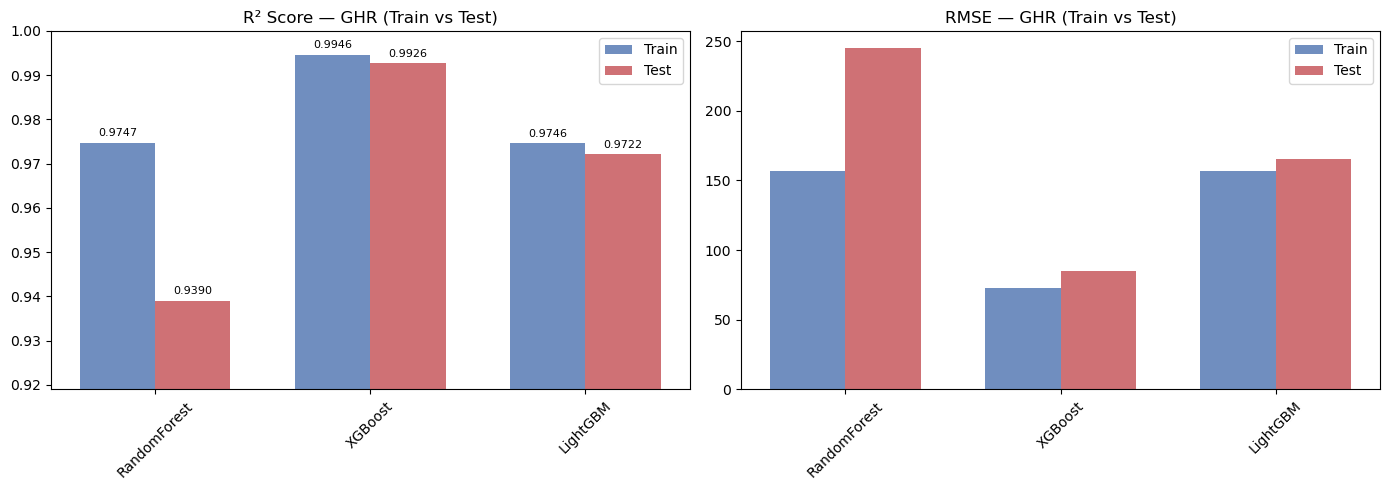

In [3]:
model_names = list(all_results.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison: Train vs Test
x = np.arange(len(model_names))
w = 0.35
train_r2 = [all_results[m]["train"]["GHR"]["R2"] for m in model_names]
test_r2 = [all_results[m]["test"]["GHR"]["R2"] for m in model_names]

bars1 = axes[0].bar(x - w/2, train_r2, w, label="Train", color="#4C72B0", alpha=0.8)
bars2 = axes[0].bar(x + w/2, test_r2, w, label="Test", color="#C44E52", alpha=0.8)
axes[0].set_title("R² Score — GHR (Train vs Test)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45)
axes[0].set_ylim(min(test_r2) - 0.02, 1.0)
axes[0].legend()
for bar, val in zip(bars1, train_r2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.4f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, test_r2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.4f}", ha="center", va="bottom", fontsize=8)

# RMSE comparison: Train vs Test
train_rmse = [all_results[m]["train"]["GHR"]["RMSE"] for m in model_names]
test_rmse = [all_results[m]["test"]["GHR"]["RMSE"] for m in model_names]

bars1 = axes[1].bar(x - w/2, train_rmse, w, label="Train", color="#4C72B0", alpha=0.8)
bars2 = axes[1].bar(x + w/2, test_rmse, w, label="Test", color="#C44E52", alpha=0.8)
axes[1].set_title("RMSE — GHR (Train vs Test)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Select Best Model

In [4]:
# Rank by Test GHR R²
rankings = {}
for name, res in all_results.items():
    gap = res["train"]["GHR"]["R2"] - res["test"]["GHR"]["R2"]
    rankings[name] = {
        "Train_R2": res["train"]["GHR"]["R2"],
        "Test_R2": res["test"]["GHR"]["R2"],
        "R2_gap": gap,
        "Test_RMSE": res["test"]["GHR"]["RMSE"],
        "inference_ms": res["inference_ms"],
    }

ranking_df = pd.DataFrame(rankings).T.sort_values("Test_R2", ascending=False)
print("Model Rankings:\n")
print(ranking_df.to_string())

best_model_name = ranking_df.index[0]
best_gap = ranking_df.iloc[0]["R2_gap"]
print(f"\n>>> Best model: {best_model_name}")
print(f"    Test R² = {ranking_df.iloc[0]['Test_R2']:.6f}")
print(f"    Train-Test gap = {best_gap:.6f} {'(no overfitting)' if best_gap < 0.01 else '(check overfitting)'}")

Model Rankings:

              Train_R2   Test_R2    R2_gap   Test_RMSE  inference_ms
XGBoost       0.994564  0.992647  0.001917   85.069654      1.044989
LightGBM      0.974619  0.972151  0.002468  165.558428      0.323296
RandomForest  0.974747  0.938983  0.035764  245.061626     16.132784

>>> Best model: XGBoost
    Test R² = 0.992647
    Train-Test gap = 0.001917 (no overfitting)


## 4. Prediction vs Actual (Best Model)

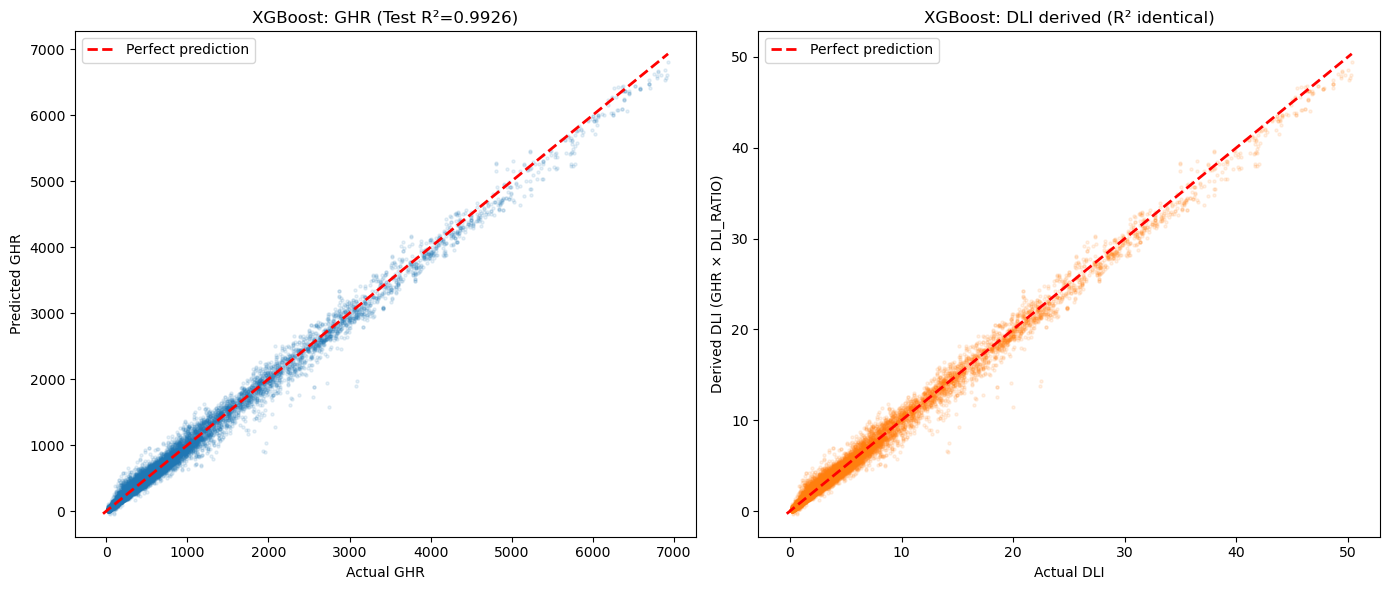

In [5]:
# Load best model and test data
X_test = pd.read_csv(f"{DATA_DIR}/X_test_tree.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv")

model_files = {
    "RandomForest": "random_forest.pkl",
    "XGBoost": "xgboost.pkl",
    "LightGBM": "lightgbm.pkl",
}
best_model = joblib.load(f"{MODEL_DIR}/{model_files[best_model_name]}")

# Single-output prediction (GHR only)
y_pred = best_model.predict(X_test)
y_pred_dli = y_pred * DLI_RATIO

# Scatter: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

yt_ghr = y_test.values.flatten()
test_r2 = all_results[best_model_name]["test"]["GHR"]["R2"]

axes[0].scatter(yt_ghr, y_pred, alpha=0.1, s=5)
lims = [min(yt_ghr.min(), y_pred.min()), max(yt_ghr.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual GHR")
axes[0].set_ylabel("Predicted GHR")
axes[0].set_title(f"{best_model_name}: GHR (Test R²={test_r2:.4f})")
axes[0].legend()

yt_dli = yt_ghr * DLI_RATIO
axes[1].scatter(yt_dli, y_pred_dli, alpha=0.1, s=5, color="tab:orange")
lims = [min(yt_dli.min(), y_pred_dli.min()), max(yt_dli.max(), y_pred_dli.max())]
axes[1].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
axes[1].set_xlabel("Actual DLI")
axes[1].set_ylabel("Derived DLI (GHR × DLI_RATIO)")
axes[1].set_title(f"{best_model_name}: DLI derived (R² identical)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Export to ONNX for Unity

Export the best model to ONNX format for Unity Barracuda inference.  
Also export a JSON config with feature names, scaler params, and encoding maps so Unity knows how to prepare inputs.

In [6]:
import onnxruntime as ort
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

n_features = X_test.shape[1]
feature_names = list(X_test.columns)

# Single model export (GHR only — DLI is derived post-prediction)
onnx_paths = {"GHR": f"{EXPORT_DIR}/daylight_model.onnx"}

# Rename features for ONNX conversion
booster = best_model.get_booster()
booster.feature_names = [f"f{i}" for i in range(n_features)]

initial_type = [("input", FloatTensorType([None, n_features]))]
onnx_model = convert_xgboost(best_model, initial_types=initial_type)

# Restore original feature names
booster.feature_names = feature_names

path = onnx_paths["GHR"]
with open(path, "wb") as f:
    f.write(onnx_model.SerializeToString())
print(f"  GHR ONNX saved: {path} ({os.path.getsize(path) / 1024:.1f} KB)")
print(f"  DLI derived in post-processing: DLI = GHR × {DLI_RATIO}")

# Verify ONNX inference matches sklearn
print("\nVerification:")
test_input = X_test.iloc[:5].values.astype(np.float32)
sklearn_pred = best_model.predict(test_input)

sess = ort.InferenceSession(path)
onnx_pred = sess.run(None, {"input": test_input})[0].flatten()
diff = np.max(np.abs(onnx_pred - sklearn_pred))
print(f"  GHR: max diff = {diff:.8f} ({'OK' if diff < 0.01 else 'CHECK'})")

# Also verify derived DLI
onnx_dli = onnx_pred * DLI_RATIO
sklearn_dli = sklearn_pred * DLI_RATIO
dli_diff = np.max(np.abs(onnx_dli - sklearn_dli))
print(f"  DLI (derived): max diff = {dli_diff:.8f} ({'OK' if dli_diff < 0.01 else 'CHECK'})")

  GHR ONNX saved: ../../models/unity_export/daylight_model.onnx (6241.3 KB)
  DLI derived in post-processing: DLI = GHR × 0.0072646

Verification:
  GHR: max diff = 0.00024414 (OK)
  DLI (derived): max diff = 0.00000143 (OK)


## 6. Unity Config (feature mapping & scaler params)

In [7]:
# Build Unity config JSON
label_encoders = joblib.load(f"{DATA_DIR}/label_encoders.pkl")

unity_config = {
    "model_name": best_model_name,
    "model_file": "daylight_model.onnx",
    "dli_ratio": DLI_RATIO,
    "feature_names": feature_names,
    "output_names": ["GHR"],
    "derived_outputs": {
        "DLI": "GHR * dli_ratio  (DLI = GHR × 0.00726460)"
    },
    "label_encodings": {
        col: dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist()))
        for col, le in label_encoders.items()
    },
    "one_hot_order": {
        "Orientation": ["E", "N", "NE", "NW", "S", "SE", "W"],
        "Level": ["G", "M", "U"],
    },
    "user_parameters": {
        "Day_of_Year": {"type": "int", "min": 1, "max": 365, "description": "Day of year (1-365)"},
        "Tree_Width_m": {"type": "int", "options": [3, 6], "description": "Tree canopy width in meters"},
        "Tree_Present": {"type": "bool", "description": "Whether trees are present (true/false)"},
        "Window_Transmittance": {"type": "float", "options": [0.1, 0.6, 0.9], "description": "Window transmittance percentage"},
        "Orientation": {"type": "string", "options": ["N", "NE", "NW", "E", "S", "SE", "W"], "description": "Facade orientation"},
        "Level": {"type": "string", "options": ["G", "M", "U"], "description": "Floor level (G=Ground, M=Middle, U=Upper)"},
        "WWR": {"type": "float", "min": 0.0, "max": 1.0, "description": "Window-to-Wall Ratio"},
    },
}

config_path = f"{EXPORT_DIR}/unity_config.json"
with open(config_path, "w") as f:
    json.dump(unity_config, f, indent=2)

print(f"Unity config saved: {config_path}")
print(f"\nSingle ONNX model: {unity_config['model_file']}")
print(f"DLI derivation ratio: {unity_config['dli_ratio']}")
print(f"\nUser-adjustable parameters in Unity:")
for param, info in unity_config["user_parameters"].items():
    print(f"  {param}: {info['description']}")

Unity config saved: ../../models/unity_export/unity_config.json

Single ONNX model: daylight_model.onnx
DLI derivation ratio: 0.0072646

User-adjustable parameters in Unity:
  Day_of_Year: Day of year (1-365)
  Tree_Width_m: Tree canopy width in meters
  Tree_Present: Whether trees are present (true/false)
  Window_Transmittance: Window transmittance percentage
  Orientation: Facade orientation
  Level: Floor level (G=Ground, M=Middle, U=Upper)
  WWR: Window-to-Wall Ratio


## 7. End-to-End Unity Inference Example

Simulates what the Unity client will do: take user parameters → encode → predict.

In [8]:
def unity_predict(onnx_path, user_input):
    """
    Simulate Unity-side inference with single ONNX model.
    Predicts GHR, then derives DLI = GHR * DLI_RATIO.
    user_input: dict with user-adjustable params.
    Note: Building is NOT a feature — the model generalizes using building
    properties (WWR, Orientation, Level, etc.) instead of building identity.
    """
    day = user_input["Day_of_Year"]
    
    # Cyclical encoding
    day_sin = np.sin(2 * np.pi * day / 365)
    day_cos = np.cos(2 * np.pi * day / 365)
    
    # Season
    if day <= 59 or day >= 335:
        season_num = 0
    elif 60 <= day <= 151:
        season_num = 1
    elif 152 <= day <= 243:
        season_num = 2
    else:
        season_num = 3
    
    season_sin = np.sin(2 * np.pi * season_num / 4)
    season_cos = np.cos(2 * np.pi * season_num / 4)
    
    # Interaction features
    tree_present_int = int(user_input["Tree_Present"])
    effective_trans = user_input["Window_Transmittance"] * (1 - tree_present_int * 0.9)
    wwr_x_trans = user_input["WWR"] * user_input["Window_Transmittance"]
    tree_effect = user_input["Tree_Width_m"] * tree_present_int
    
    # One-hot encode (no Building — only Orientation and Level)
    orientations = ["E", "N", "NE", "NW", "S", "SE", "W"]
    levels = ["G", "M", "U"]
    
    ori_ohe = [1 if o == user_input["Orientation"] else 0 for o in orientations]
    lvl_ohe = [1 if l == user_input["Level"] else 0 for l in levels]
    
    features = np.array([[
        day, tree_present_int, user_input["Window_Transmittance"],
        user_input["WWR"], user_input["Tree_Width_m"],
        day_sin, day_cos, season_sin, season_cos,
        *ori_ohe, *lvl_ohe,
        effective_trans, wwr_x_trans, tree_effect,
    ]], dtype=np.float32)
    
    # Run single ONNX model for GHR
    sess = ort.InferenceSession(onnx_path)
    pred = sess.run(None, {"input": features})[0].flatten()[0]
    
    result = {"GHR": float(pred)}
    result["DLI"] = result["GHR"] * DLI_RATIO  # Derive DLI from GHR
    
    return result


# Test with example input (no Building parameter needed)
example = {
    "Day_of_Year": 180,
    "Tree_Width_m": 3,
    "Tree_Present": True,
    "Window_Transmittance": 0.6,
    "Orientation": "NE",
    "Level": "U",
    "WWR": 0.3
}

onnx_model_path = onnx_paths["GHR"]
result = unity_predict(onnx_model_path, example)
print(f"Example Unity prediction:")
print(f"  Input: {example}")
print(f"  Output: GHR={result['GHR']:.2f}, DLI={result['DLI']:.4f} (derived)")

# Seasonal comparison
print("\nSeasonal comparison (NE, Upper, WWR=0.3, Trees=True, 3m, Trans=0.6):")
for day, label in [(15, "Winter"), (100, "Spring"), (180, "Summer"), (280, "Autumn")]:
    ex = {**example, "Day_of_Year": day}
    r = unity_predict(onnx_model_path, ex)
    print(f"  {label} (day {day}): GHR={r['GHR']:.1f}, DLI={r['DLI']:.3f} (derived)")

Example Unity prediction:
  Input: {'Day_of_Year': 180, 'Tree_Width_m': 3, 'Tree_Present': True, 'Window_Transmittance': 0.6, 'Orientation': 'NE', 'Level': 'U', 'WWR': 0.3}
  Output: GHR=382.23, DLI=2.7767 (derived)

Seasonal comparison (NE, Upper, WWR=0.3, Trees=True, 3m, Trans=0.6):


  Winter (day 15): GHR=56.5, DLI=0.411 (derived)
  Spring (day 100): GHR=170.7, DLI=1.240 (derived)


  Summer (day 180): GHR=382.2, DLI=2.777 (derived)


  Autumn (day 280): GHR=339.5, DLI=2.466 (derived)


## Summary

**Best Model: XGBoost** (GHR R² ≈ 0.993)

**Single-target approach:** The model predicts **GHR only**. DLI is derived post-prediction via `DLI = GHR × 0.00726460`.

**Exported for Unity (`models/unity_export/`):**
- `daylight_model.onnx` — Single XGBoost model for GHR prediction
- `unity_config.json` — feature names, one-hot encoding order, parameter definitions, and `dli_ratio` for deriving DLI

**Unity integration:** Load one ONNX model with Barracuda, encode user inputs using `unity_config.json`, run inference to get GHR, then multiply by `dli_ratio` to obtain DLI.